## Portfolio - Predicción de goles en partidos FIFA WC26

### Limpieza de datos,  Modelación y Predicción de goles

En este paso se realizan los siguientes pasos:

1. Conexión API a los partidos FIFA WC26
2. Limpieza y transformación de columnas
3. Creación de variables para el modelo
3. Modelación
4. Predicción Partidos

Paso 1 - Librerias a importar

- Pandas
- numpy
- requests
- utils2.py (archivo con funciones de limpieza y captura de datos)

In [1]:
import pandas as pd
from datetime import datetime
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf

import utils2 as utils

Paso 2 - Obtener datos FIFA WC26 por API (partidos, games y estadios)

[Revisar repo - Github FIFA WC26 API](https://github.com/rezarahiminia/worldcup2026)

In [13]:
# 1. Obtener los próximos partidos (vía API o descarga directa)
url_g = "https://worldcup26.ir/get/games"
url_t = "https://worldcup26.ir/get/teams"
url_s = "https://worldcup26.ir/get/stadiums"

response = requests.get(url_g)
calendario = response.json()
response = requests.get(url_t)
teams = response.json()
response = requests.get(url_s)
stadiums = response.json()

#Paises y Estadios
dict_estadios = utils.crear_diccionario_estadios(stadiums)
id_to_fifa = {team['id']: team['fifa_code'] for team in teams['teams']}
name_to_fifa = {team['id']: team['name_en'] for team in teams['teams']}

Estandarizar BBDD FIFA WC26

In [43]:
df_wc = utils.preparar_calendario(calendario['games'])
#df_wc = df_wc[df_wc['Team_id'] != "0"].copy() #Descarta partidos sin asignación de equipos
df_wc['Team'] = df_wc['Team_id'].map(id_to_fifa)
df_wc['Date'] = pd.to_datetime(df_wc['Date']).dt.strftime("%Y-%m-%d")
df_wc['Game_type'] = 'FIFA WC26'
df_wc['Venue'] = df_wc['stadium_id'].map(dict_estadios)
df_wc['Condition'] = np.where(df_wc['Team'].isin(['CAN','MEX','USA']), 'L', 'N')
df_wc['Opponent'] = df_wc['Opponent_id'].map(name_to_fifa)
df_wc['Goals_team'] = pd.to_numeric(df_wc['home_score'], errors='coerce')
df_wc['Goals_opponent'] = pd.to_numeric(df_wc['away_score'], errors='coerce')
df_wc['Penalties'] = np.where(df_wc['Game_id'].isin(['74','75','82','86','88','96']), True, False)
df_wc['AET'] = np.where(df_wc['Game_id'].isin(['74','75','88','96','99','100']), True, False)

In [44]:
# 1. Obtenemos los índices (las posiciones reales) de la primera y última fila que cumplen tu condición
idx_head = df_wc[df_wc['Game_id'] == '103'].index[0]  # El equivalente a tu head(1)
idx_tail = df_wc[df_wc['Game_id'] == '103'].index[-1] # El equivalente a tu tail(1)

# 2. Modificamos el DataFrame original directamente usando .loc
df_wc.loc[idx_head, 'Team'] = 'FRA'
df_wc.loc[idx_head, 'Opponent'] = 'England'

df_wc.loc[idx_tail, 'Team'] = 'ENG'
df_wc.loc[idx_tail, 'Opponent'] = 'France'

idx_head = df_wc[df_wc['Game_id'] == '104'].index[0]  # El equivalente a tu head(1)
idx_tail = df_wc[df_wc['Game_id'] == '104'].index[-1] # El equivalente a tu tail(1)

# 2. Modificamos el DataFrame original directamente usando .loc
df_wc.loc[idx_head, 'Team'] = 'ESP'
df_wc.loc[idx_head, 'Opponent'] = 'Argentina'

df_wc.loc[idx_tail, 'Team'] = 'ARG'
df_wc.loc[idx_tail, 'Opponent'] = 'Spain'

df_wc = df_wc[['Team', 'Date', 'Game_type', 'Venue', 'Condition', 'Opponent', 
        'Goals_team', 'Goals_opponent', 'Penalties', 'AET', 'Game_id']].copy()

Penalties & AET

Juntar BBDD para transformación y limpieza

In [46]:
df_games = pd.read_parquet('../database/games.parquet').drop(columns=['Resultado_Original'])
df_games = df_games[pd.to_datetime(df_games['Date']).dt.date < pd.Timestamp('2026-06-11').date()].copy()
df_games = pd.concat([df_games, df_wc])

Paso 3 - Limpieza y transformacion de variables

In [47]:
# Codigo FIFA Oponente
country_dict = pd.read_parquet('../database/ranking_fifa.parquet').set_index('Seleccion')['Codigo_Pais'].to_dict()
mapa_final = country_dict | utils.mapa_nombres

df_games['Opponent2'] = df_games['Opponent'].map(mapa_final)
df_games = df_games[df_games['Opponent2'].notna()].copy()

df_games['Goals_team'].fillna(0, inplace=True)
df_games['Goals_opponent'].fillna(0, inplace=True)

# Torneos
df_games['Game_type'] = df_games['Game_type'].apply(utils.reclass_torneos)
print(df_games['Game_type'].value_counts())

Game_type
Friendly          579
Federation Cup    567
WC Qualifiers     517
Nations League    211
World Cup         208
Other             136
Name: count, dtype: int64


Filtro selecciones que quedan

In [48]:
teams_r32 = ['ALG', 'ARG', 'AUS', 'AUT', 'BEL', 'BIH', 'BRA', 'CAN', 'CIV', 'COD', 'COL', 'CPV', 'CRO', 'ECU', 'EGY', 'ENG', 'ESP', 'FRA', 'GER', 'GHA', 'JPN', 'MAR', 'MEX', 'NED', 'NOR', 'PAR', 'POR', 'RSA', 'SEN', 'SUI', 'SWE', 'USA']
teams_r16 = ['ARG', 'BEL', 'BRA', 'CAN', 'COL', 'EGY', 'ENG', 'ESP', 'FRA', 'MAR', 'MEX', 'NOR', 'PAR', 'POR', 'SUI', 'USA']
teams_r8 = ['ARG', 'BEL', 'ENG', 'ESP', 'FRA', 'MAR', 'NOR', 'SUI']
#df_games = df_games[df_games['Team'].isin(teams_r8)].copy()
print(df_games['Game_type'].value_counts())

Game_type
Friendly          579
Federation Cup    567
WC Qualifiers     517
Nations League    211
World Cup         208
Other             136
Name: count, dtype: int64


4 - Creación variables al modelo

Las variables a utilizar son las siguientes:

**Fecha**: Se utilizará un decaimiento exponencial a la diferencia en días entre el 20/Jul/26 (Día posterior a la final FIFA WC26) y el día del partido.

**Es_Local**: Variable binaria si el equipo está en condición de local.

**AET_LastGame**: Variable binaria que indica si el partido anterior hubo alarge (Added Extra Time - AET).

**Game_type**: Tipo de competicion (Amistoso, Clasificatoria, Copa de Federaciones (Euro, America, Asia, ...))

**goals_team_avg**: N goles convertidos por el equipo en los últimos 5 partidos.

**goals_avg**: N goles convertidos en los últimos 5 partidos

In [49]:
df_games.shape

(2218, 12)

In [50]:
last_games = 5
df_games = utils.calcular_decaimiento_exponencial(df_games, alpha=0.01)
df_games['Es_Local'] = (df_games['Condition'] == 'L').astype(int)
df_games = utils.crear_ventana_fatiga(df_games)
df_games = utils.calcular_estadisticas_moviles(df_games, ventana=last_games)
df_games['Weight'] = df_games['Game_type'].apply(utils.asignar_peso)
#df_games = df_games.dropna()
print(df_games.shape)


(2218, 18)


**z-score_rank**: Diferencia estandarizada en el ranking FIFA entre la selección y su equipo Oponente. En vez de usar el nmro de ranking, se usan los puntos FIFA. 

Para ello se usa el último ranking FIFA, se calcula la diferencia en puntos entre la selección y su oponente. Al ser una variable numérica, se estandariza en media y varianza.

Adicionalmente, para descartar datos anómalos, se descartan partidos con más de 10 goles y partidos con diferencia en puntos FIFA muy alto (Diferencia en ptos FIFA entre -650 y 650 ptos).

In [51]:
scaler = StandardScaler()
df_ranking = pd.read_parquet('../database/ranking_fifa.parquet')
ranking_dict = dict(zip(df_ranking['Codigo_Pais'], df_ranking['Puntos_FIFA']))

df_games['Ranking_Team'] = df_games['Team'].map(ranking_dict)
df_games['Ranking_Opponent'] = df_games['Opponent2'].map(ranking_dict)
df_games['Ranking_diff'] = df_games['Ranking_Team'] - df_games['Ranking_Opponent']

df_games = df_games[df_games['Goals_team'] < 9].copy() #Descartar partidos con más de 10 goles

df_games = df_games[(df_games['Ranking_diff'] < 650)&(df_games['Ranking_diff'] > -650)].copy() #Descartar partidos con más de 10 goles
df_games['Zscore_Rank'] = scaler.fit_transform(df_games[['Ranking_diff']])
print(df_games.shape)


(2150, 22)


Separar datos de predicción con los de entrenamiento

Los datos de predicción son los partidos que aún no se realizan

In [52]:
date_filter = df_games['Date'].dt.normalize() <= (pd.Timestamp.now()).normalize()

df_train = df_games[date_filter].copy()
df_test = df_games[~date_filter].copy()

In [53]:
df_train[df_train['Game_type']=='World Cup'].sort_values(by='Date')

,Team,Date,Game_type,Venue,Condition,Opponent,Goals_team,Goals_opponent,Penalties,AET,...,Date_decay,Es_Local,AET_LastGame,goals_team_avg,goals_avg,Weight,Ranking_Team,Ranking_Opponent,Ranking_diff,Zscore_Rank
1,RSA,2026-06-11,World Cup,"Estadio Azteca, Mexico City, Mexico",N,Mexico,0.0,2.0,False,False,...,0.677057,0,0,0.8,2.0,0.8,1418.211807,1721.782405,-303.570598,-1.913531
2,KOR,2026-06-11,World Cup,"Estadio Akron, Guadalajara (Zapopan), Mexico",N,Czech Republic,2.0,1.0,False,False,...,0.677057,0,0,1.4,2.4,0.8,1591.749573,1481.485998,110.263575,-0.144745
0,MEX,2026-06-11,World Cup,"Estadio Azteca, Mexico City, Mexico",L,South Africa,2.0,0.0,False,False,...,0.677057,1,0,1.8,2.2,0.8,1721.782405,1418.211807,303.570598,0.681476
3,CZE,2026-06-11,World Cup,"Estadio Akron, Guadalajara (Zapopan), Mexico",N,South Korea,1.0,2.0,False,False,...,0.677057,0,0,3.0,4.2,0.8,1481.485998,1591.749573,-110.263575,-1.087309
7,PAR,2026-06-12,World Cup,"SoFi Stadium, Los Angeles (Inglewood), United ...",N,United States,1.0,4.0,False,False,...,0.683861,0,0,1.8,2.8,0.8,1488.048969,1709.589988,-221.541019,-1.562925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,SUI,2026-07-11,World Cup,"GEHA Field at Arrowhead Stadium, Kansas City, ...",N,Argentina,1.0,3.0,False,True,...,0.913931,0,1,1.8,2.4,0.8,1654.939343,1889.062265,-234.122922,-1.616701
201,ESP,2026-07-14,World Cup,"AT&T Stadium, Dallas (Arlington, Texas), Unite...",N,France,2.0,0.0,False,False,...,0.941765,0,0,2.2,2.4,0.8,1856.033671,1887.107625,-31.073954,-0.748842
200,FRA,2026-07-14,World Cup,"AT&T Stadium, Dallas (Arlington, Texas), Unite...",N,Spain,0.0,2.0,False,False,...,0.941765,0,0,2.6,2.8,0.8,1887.107625,1856.033671,31.073954,-0.483213
202,ENG,2026-07-15,World Cup,"Mercedes-Benz Stadium, Atlanta, United States",N,Argentina,1.0,2.0,False,False,...,0.951229,0,1,1.8,2.6,0.8,1847.677458,1889.062265,-41.384807,-0.792912


In [54]:
df_test

,Team,Date,Game_type,Venue,Condition,Opponent,Goals_team,Goals_opponent,Penalties,AET,...,Date_decay,Es_Local,AET_LastGame,goals_team_avg,goals_avg,Weight,Ranking_Team,Ranking_Opponent,Ranking_diff,Zscore_Rank
207,ARG,2026-07-19,World Cup,"MetLife Stadium, New York/New Jersey (East Rut...",N,Spain,0.0,0.0,False,False,...,0.990050,0,0,2.8,4.2,0.8,1889.062265,1856.033671,33.028594,-0.474858
205,ENG,2026-07-18,World Cup,"Hard Rock Stadium, Miami (Miami Gardens), Unit...",N,France,0.0,0.0,False,False,...,0.980199,0,0,2.0,3.2,0.8,1847.677458,1887.107625,-39.430167,-0.784557
206,ESP,2026-07-19,World Cup,"MetLife Stadium, New York/New Jersey (East Rut...",N,Argentina,0.0,0.0,False,False,...,0.990050,0,0,1.8,2.0,0.8,1856.033671,1889.062265,-33.028594,-0.757196
204,FRA,2026-07-18,World Cup,"Hard Rock Stadium, Miami (Miami Gardens), Unit...",N,England,0.0,0.0,False,False,...,0.980199,0,0,2.0,2.6,0.8,1887.107625,1847.677458,39.430167,-0.447497


Paso 4 - Modelación

Antes de aplicar GLM Poission, revisamos descriptivamente los datos

Variable respuesta

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


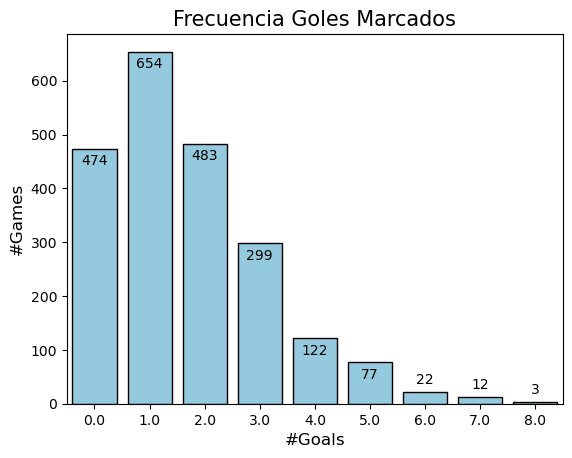

In [55]:
# Usamos countplot en lugar de histplot para datos discretos
# Esto asegura que cada columna esté alineada exactamente con el número de goles
ax = sns.countplot(data=df_train, x='Goals_team', color='skyblue', edgecolor='black')

# Añadir etiquetas de cantidad sobre cada barra para mayor claridad
for p in ax.patches:
    if p.get_x() < 5 :
        ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, -9), 
                textcoords='offset points')
    else :
        ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')
    
plt.title('Frecuencia Goles Marcados', fontsize=15)
plt.xlabel('#Goals', fontsize=12)
plt.ylabel('#Games', fontsize=12)
plt.savefig('../imgs/goals.png')

Validación gráfica otras variables

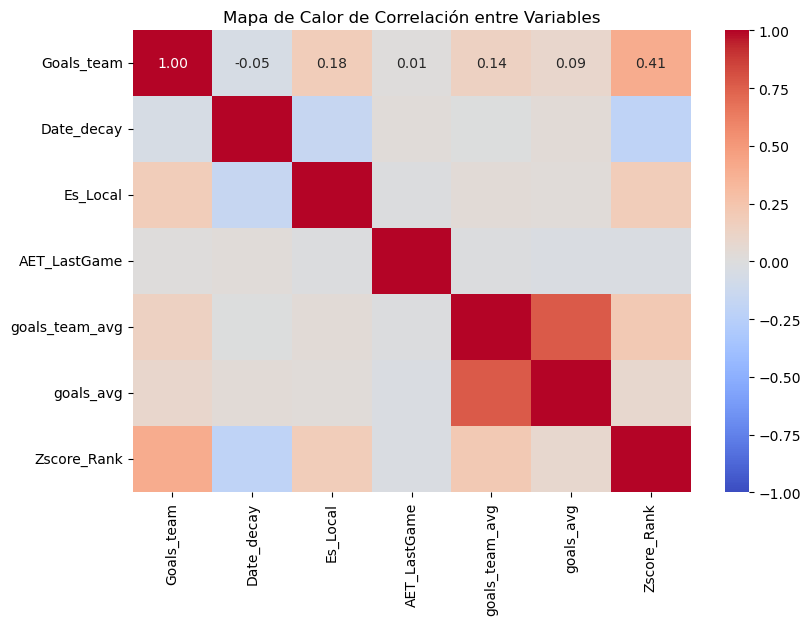

In [56]:
vars = ['Goals_team', 'Date_decay', 'Es_Local', 'AET_LastGame', 'goals_team_avg', 'goals_avg', 'Zscore_Rank']
# Calculamos la matriz de correlación
correlacion = df_train[vars].corr()

# Creamos el mapa de calor
plt.figure(figsize=(9, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Mapa de Calor de Correlación entre Variables')
plt.savefig('../imgs/corr.png')

Modelación / Cantidad de goles ~ Modelo GLM Poisson

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 2146
Model:                            GLM   Df Residuals:                     2134
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3365.2
Date:               mié, 15 jul. 2026   Deviance:                       2461.0
Time:                        18:55:49   Pearson chi2:                 2.15e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2171
Covariance Type:            nonrobust                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

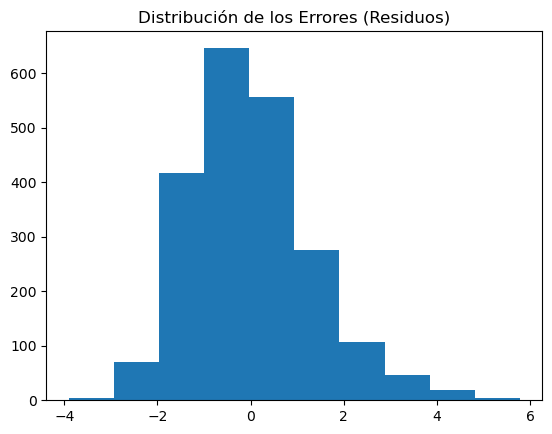

In [57]:
formula = "Goals_team ~ Date_decay + C(Game_type) + Zscore_Rank + Es_Local + goals_team_avg + goals_avg + AET_LastGame"

# Ajuste del modelo
model_1 = smf.glm(formula=formula, data=df_train, family=sm.families.Poisson()).fit()
                #var_weights=df_final['Peso_Partido']).fit()

df_model_1 = df_train.copy()
df_model_1['Prediccion'] = model_1.predict(df_model_1)
df_model_1['Error'] = df_model_1['Goals_team'] - df_model_1['Prediccion']

print(model_1.summary())
print("******* AIC:",model_1.aic,"*******")
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_1['Error'], bins=10)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Modelo sin variables Redundantes

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 2146
Model:                            GLM   Df Residuals:                     2142
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3389.7
Date:               mié, 15 jul. 2026   Deviance:                       2510.0
Time:                        19:10:36   Pearson chi2:                 2.20e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1989
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.2904      0.055      5.243      

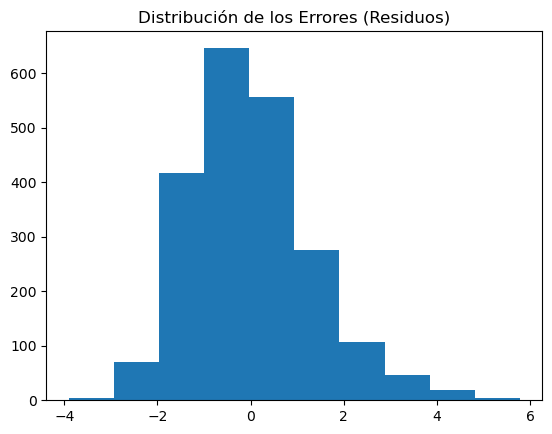

In [78]:
formula = "Goals_team ~ Date_decay + Zscore_Rank + goals_avg"
# Ajuste del modelo
model_2 = smf.glm(formula=formula, data=df_train, family=sm.families.Poisson()).fit()
                #var_weights=df_final['Peso_Partido']).fit()

df_model_2 = df_train.copy()
df_model_2['Prediccion'] = model_1.predict(df_model_2)
df_model_2['Error'] = df_model_2['Goals_team'] - df_model_2['Prediccion']

print(model_2.summary())
print("******* AIC:",model_2.aic,"*******")
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_2['Error'], bins=10)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Modelo con ponderador según torneo

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 2146
Model:                            GLM   Df Residuals:                     2142
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1838.5
Date:               mié, 15 jul. 2026   Deviance:                       1354.6
Time:                        19:10:46   Pearson chi2:                 1.19e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1174
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.2836      0.075      3.758      

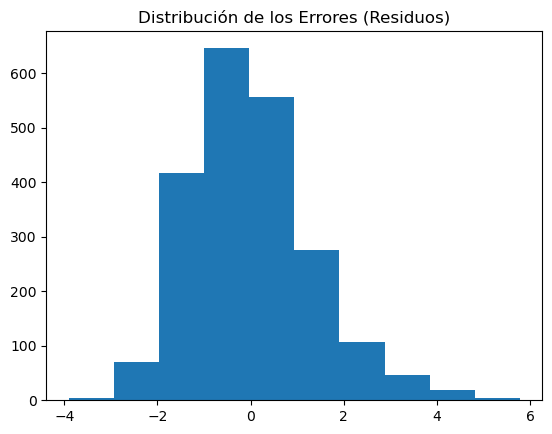

In [79]:
formula = "Goals_team ~ Date_decay + Zscore_Rank + goals_avg"
#"Goals_team ~ Date_decay + Zscore_Rank + goals_team_avg"

# Ajuste del modelo
model_3 = smf.glm(formula=formula, data=df_train, family=sm.families.Poisson(),
                var_weights=df_train['Weight']).fit()

df_model_3 = df_train.copy()
df_model_3['Prediccion'] = model_1.predict(df_model_2)
df_model_3['Error'] = df_model_3['Goals_team'] - df_model_3['Prediccion']

print(model_3.summary())
print("******* AIC:",model_3.aic,"*******")
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_3['Error'], bins=10)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Comparacion entre modelos

Para ello usamos el críterio de Akaike

In [80]:
print(f"M1: {model_1.aic}")
print(f"M2: {model_2.aic}")
print(f"M3: {model_3.aic}")

M1: 6754.338047535843
M2: 6787.422910622686
M3: 3684.948654697272


El modelo es aquel con menos críterio de Akaike, es decir, el modelo con ponderador por tipo de Torneo

In [81]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(df_model_3['Goals_team'], df_model_3['Prediccion'])
print(f"Error promedio: {mae:.2f} goles por partido")

Error promedio: 1.03 goles por partido


In [73]:
# Identificar partidos donde el error es mayor a 2 goles
df_model_3['Abs_Error'] = abs(df_model_3['Error'])
fallos_graves = df_model_3.sort_values(by='Abs_Error', ascending=False).head(10)
print(fallos_graves[['Date', 'Team', 'Opponent', 'Goals_team', 'Prediccion','Ranking_diff']])

           Date Team     Opponent  Goals_team  Prediccion  Ranking_diff
256  2024-11-15  NZL      Vanuatu         8.0    2.222128    287.510892
597  2023-11-16  QAT  Afghanistan         8.0    2.718208    470.744174
1238 2025-11-13  CUW      Bermuda         7.0    1.823042    311.942393
257  2024-11-18  NZL        Samoa         8.0    2.878276    413.633591
820  2026-03-27  ALG    Guatemala         7.0    1.959477    320.493849
1480 2024-06-07  CZE        Malta         7.0    2.450240    488.692501
1941 2025-06-17  CAN     Honduras         6.0    1.468905    193.163121
1368 2024-03-26  AUT       Turkey         6.0    1.492272     33.389825
258  2025-03-21  NZL         Fiji         7.0    2.498333    265.868755
703  2024-06-06  KOR    Singapore         7.0    2.531585    533.799361


Gráfico de Ranking_diff

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


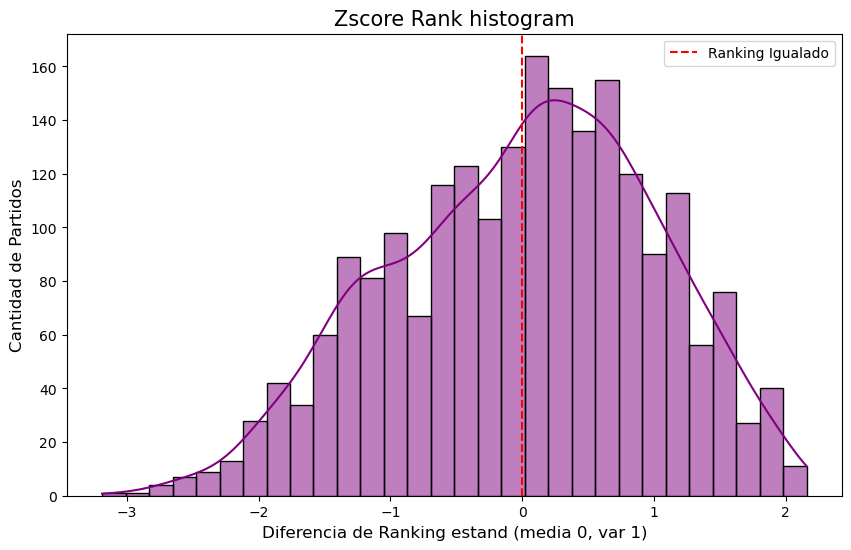

In [82]:
plt.figure(figsize=(10, 6))

# Histograma con KDE para ver la distribución
sns.histplot(df_train['Zscore_Rank'], kde=True, bins=30, color='purple', edgecolor='black')

# Línea vertical en 0 (Equipos de igual ranking)
plt.axvline(0, color='red', linestyle='--', label='Ranking Igualado')

plt.title('Zscore Rank histogram', fontsize=15)
plt.xlabel('Diferencia de Ranking estand (media 0, var 1)', fontsize=12)
plt.ylabel('Cantidad de Partidos', fontsize=12)
plt.legend()
plt.savefig('../imgs/Zscore_dist.png')

Predicción próximos partidos

In [83]:
df_goals_upd = df_train.sort_values(['Team', 'Date']).groupby('Team').tail(last_games)
df_goals_upd['total_goals'] = df_goals_upd['Goals_team'] + df_goals_upd['Goals_opponent']
metricas_recientes = df_goals_upd.groupby('Team').agg({'Goals_team': 'mean','total_goals': 'mean'}).rename(
    columns={'total_goals':'goals_avg', 'Goals_team':'goals_team_avg'})
metricas_recientes.sample(3)

df_test = df_test.drop(columns = ['goals_team_avg', 'goals_avg']).merge(metricas_recientes, on='Team', how='left')

In [84]:
df_test['Model_predict'] = model_3.predict(df_test)
df_test['Goles_Estimados'] = df_test['Model_predict'].astype(int)
df_test['Goles_Estimados'] = np.where(df_test['Model_predict']<1.3, df_test['Model_predict'].astype(int), df_test['Model_predict'].round(0).astype(int))

In [85]:
print(df_test[['Team', 'Opponent', 'Goles_Estimados','Model_predict']])

  Team   Opponent  Goles_Estimados  Model_predict
0  ARG      Spain                2       1.579974
1  ENG     France                1       1.328049
2  ESP  Argentina                1       1.257231
3  FRA    England                1       1.459476


In [46]:
filtro = df_test['Date'].dt.date == pd.Timestamp('2026-07-04').date()
df_hoy = df_test[filtro]
print(df_hoy[['Team', 'Opponent', 'Goles_Estimados','Model_predict']])

   Team  Opponent  Goles_Estimados  Model_predict
3   CAN   Morocco                1       1.194530
8   FRA  Paraguay                3       2.946307
9   MAR    Canada                2       2.386029
12  PAR    France                0       0.967374


Guardar pronóstico

In [68]:
df_test.to_parquet('../database/predictions_r2.parquet')